In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
figure_dir = "../artifacts/figures"
result_dir = "../artifacts/model_results"

os.makedirs(figure_dir,exist_ok=True)
os.makedirs(result_dir,exist_ok=True)


In [3]:
file_path = "../data/processed/cleaned_customer_churn.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(7043, 21)


In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
df["TotalCharges"] = (df["TotalCharges"].fillna(0))

In [5]:
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"No": 0,"Yes": 1})

print("Churn Distribution:")
print(df["Churn"].value_counts())

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [6]:
customer_ids = df["customerID"].copy()

In [7]:
X = df.drop(columns=["customerID","Churn"])
y = df["Churn"]

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test,id_train,id_test = train_test_split(X,y,customer_ids,test_size=0.20,random_state=42,stratify=y)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(5634, 19)
Testing Data Shape:
(1409, 19)


In [9]:
import joblib

model_path = "../artifacts/models/best_churn_model.pkl"
best_model = joblib.load(model_path)

print("Best Model Pipeline:")
print(best_model)

Best Model Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                             

In [10]:
y_pred = best_model.predict(X_test)

y_probability = (best_model.predict_proba(X_test)[:, 1])


In [11]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_probability)

In [12]:
print("FINAL MODEL PERFORMANCE")
print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

FINAL MODEL PERFORMANCE

Accuracy  : 0.7395
Precision : 0.5060
Recall    : 0.7834
F1 Score  : 0.6149
ROC-AUC   : 0.8415


In [13]:
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=["Stayed","Churned"]))



Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [14]:
performance_df = pd.DataFrame([{
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "ROC_AUC": roc_auc
        }])

performance_df.to_csv(os.path.join(result_dir,"final_model_evaluation.csv"),index=False)

In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)


print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print("\nTrue Negatives:")

print(tn)
print("\nFalse Positives:")

print(fp)
print("\nFalse Negatives:")
print(fn)

print("\nTrue Positives:")
print(tp)


Confusion Matrix:
[[749 286]
 [ 81 293]]

True Negatives:
749

False Positives:
286

False Negatives:
81

True Positives:
293


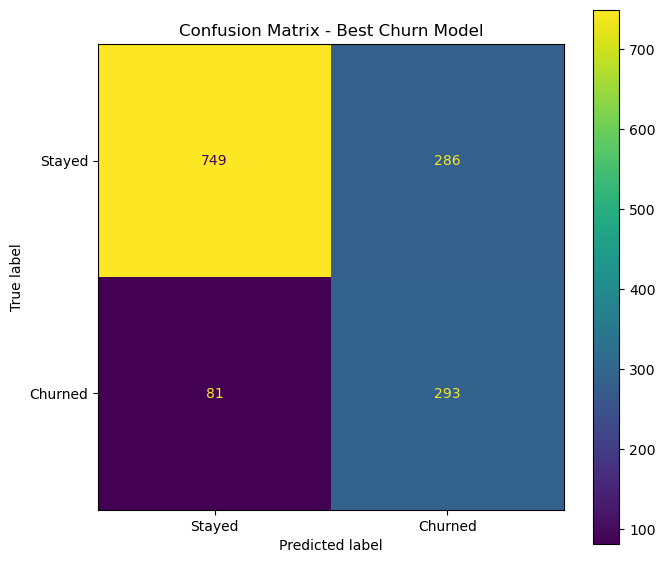

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Stayed","Churned"])

fig, ax = plt.subplots(figsize=(7, 6))
display.plot(ax=ax,values_format="d")

plt.title("Confusion Matrix - Best Churn Model")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"confusion_matrix.png"),dpi=300)

plt.show()

In [17]:
from sklearn.metrics import roc_curve
false_positive_rate, true_positive_rate, thresholds = (roc_curve(y_test,y_probability))

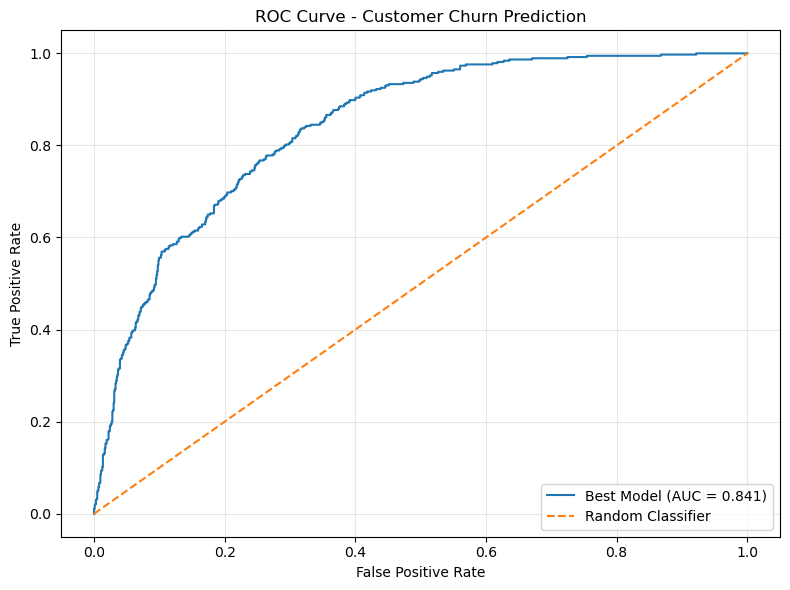

In [18]:
plt.figure(figsize=(8, 6))

plt.plot(false_positive_rate,true_positive_rate,label=f"Best Model (AUC = {roc_auc:.3f})")


# Random classifier line

plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"roc_curve.png"),dpi=300)

plt.show()

In [19]:
preprocessor = (best_model.named_steps["preprocessor"])

selector = (best_model.named_steps["selector"])
classifier = (best_model.named_steps["classifier"])

In [20]:
all_feature_names = np.array(preprocessor.get_feature_names_out())

print("\nNumber of Features After Preprocessing:")
print(len(all_feature_names))



Number of Features After Preprocessing:
30


In [21]:
selected_mask = (selector.get_support())
selected_feature_names = (all_feature_names[selected_mask])
print("\nNumber of Selected Features:")
print(len(selected_feature_names))



Number of Selected Features:
30


In [22]:
coefficients = (classifier.coef_[0])

print("\nNumber of Coefficients:")
print(len(coefficients))



Number of Coefficients:
30


In [23]:
coefficient_df = pd.DataFrame({
        "Feature":selected_feature_names,
        "Coefficient":coefficients
    })

In [24]:
coefficient_df["Feature"] = (coefficient_df["Feature"].str.replace("numerical__","",regex=False).str.replace("categorical__","",regex=False))

In [25]:
coefficient_df["Absolute_Coefficient"] = (coefficient_df["Coefficient"].abs())


In [26]:
coefficient_df = (coefficient_df.sort_values("Absolute_Coefficient",ascending=False).reset_index(drop=True))

print("\nTop Model Coefficients:")
print(coefficient_df.head(20))


Top Model Coefficients:
                                 Feature  Coefficient  Absolute_Coefficient
0                                 tenure    -1.153097              1.153097
1                         MonthlyCharges    -0.936834              0.936834
2            InternetService_Fiber optic     0.769146              0.769146
3                      Contract_Two year    -0.614918              0.614918
4                           TotalCharges     0.486101              0.486101
5                       PhoneService_Yes     0.428436              0.428436
6         MultipleLines_No phone service     0.400083              0.400083
7                      Contract_One year    -0.295496              0.295496
8                    StreamingMovies_Yes     0.269618              0.269618
9                        StreamingTV_Yes     0.256770              0.256770
10                     MultipleLines_Yes     0.193660              0.193660
11        PaymentMethod_Electronic check     0.190673          

In [27]:
positive_coefficients = (coefficient_df[coefficient_df["Coefficient"] > 0].sort_values("Coefficient",ascending=False))

print("\nFeatures Associated With Higher Churn:")
print(positive_coefficients[["Feature","Coefficient"]].head(15))


Features Associated With Higher Churn:
                                  Feature  Coefficient
2             InternetService_Fiber optic     0.769146
4                            TotalCharges     0.486101
5                        PhoneService_Yes     0.428436
6          MultipleLines_No phone service     0.400083
8                     StreamingMovies_Yes     0.269618
9                         StreamingTV_Yes     0.256770
10                      MultipleLines_Yes     0.193660
11         PaymentMethod_Electronic check     0.190673
12                   PaperlessBilling_Yes     0.164819
23                          SeniorCitizen     0.056746
24                   DeviceProtection_Yes     0.050555
25             PaymentMethod_Mailed check     0.023309
26                            gender_Male     0.016550
27                            Partner_Yes     0.008832
29  PaymentMethod_Credit card (automatic)     0.000895


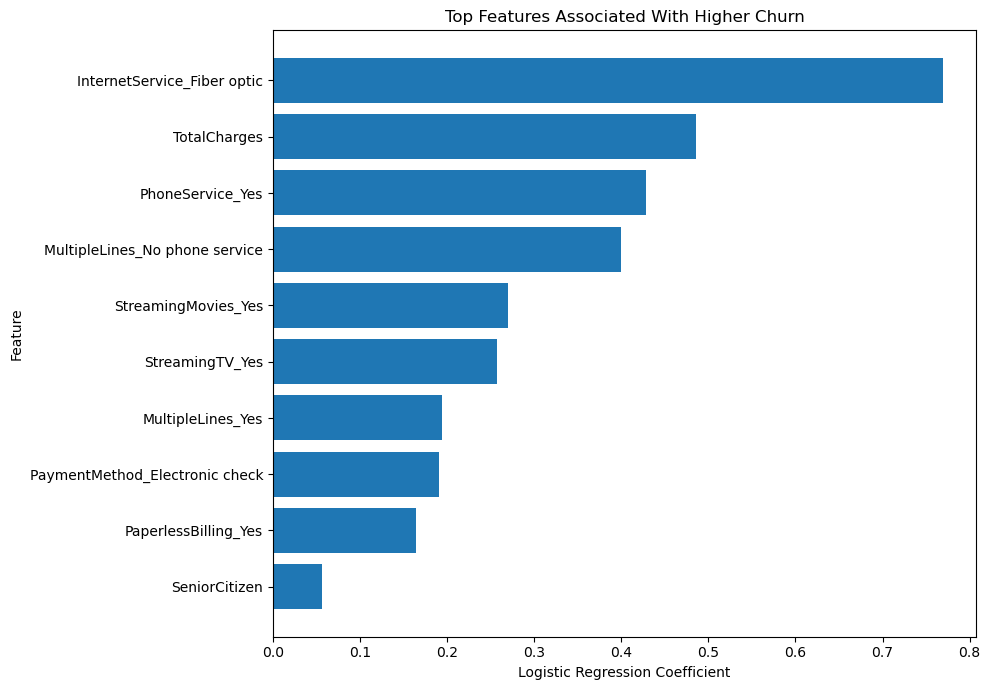

In [28]:
top_positive = (positive_coefficients.head(10).sort_values("Coefficient"))

plt.figure(figsize=(10, 7))

plt.barh(top_positive["Feature"],top_positive["Coefficient"])

plt.title("Top Features Associated With Higher Churn")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"positive_churn_drivers.png"),dpi=300)

plt.show()

In [29]:
negative_coefficients = (coefficient_df[coefficient_df["Coefficient"] < 0].sort_values("Coefficient",ascending=True))

print("\nFeatures Associated With Lower Churn:")
print(negative_coefficients[["Feature","Coefficient"]].head(15))



Features Associated With Lower Churn:
                                 Feature  Coefficient
0                                 tenure    -1.153097
1                         MonthlyCharges    -0.936834
3                      Contract_Two year    -0.614918
7                      Contract_One year    -0.295496
13                    OnlineSecurity_Yes    -0.121360
14                        Dependents_Yes    -0.104667
15       TechSupport_No internet service    -0.093908
16   StreamingMovies_No internet service    -0.093908
17       StreamingTV_No internet service    -0.093908
18    OnlineSecurity_No internet service    -0.093908
19  DeviceProtection_No internet service    -0.093908
20      OnlineBackup_No internet service    -0.093908
21                    InternetService_No    -0.093908
22                       TechSupport_Yes    -0.091366
28                      OnlineBackup_Yes    -0.003411


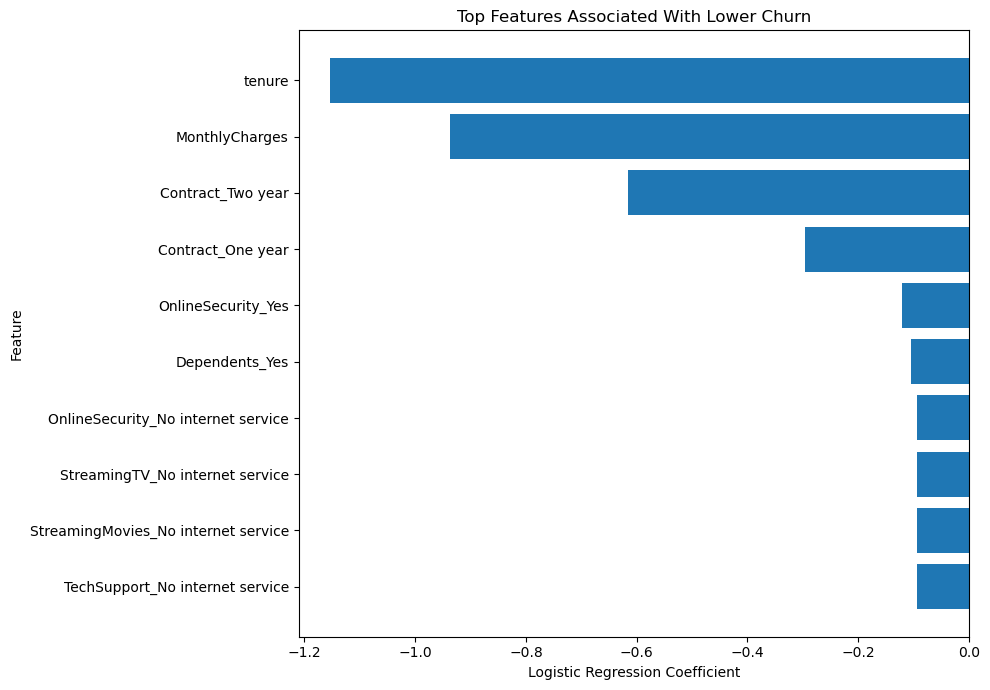

In [30]:
top_negative = (negative_coefficients.head(10).sort_values("Coefficient",ascending=False))
plt.figure(figsize=(10, 7))

plt.barh(top_negative["Feature"],top_negative["Coefficient"])
plt.title("Top Features Associated With Lower Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(figure_dir,"negative_churn_drivers.png"),dpi=300)
plt.show()


In [31]:
customer_predictions = pd.DataFrame({
        "customerID":id_test.values,
        "Actual_Churn":y_test.values,
        "Predicted_Churn":y_pred,
        "Churn_Probability":y_probability
    })


In [32]:
def assign_probability_risk(probability):
    if probability >= 0.75:
        return "Very High"
    elif probability >= 0.50:
        return "High"
    elif probability >= 0.25:
        return "Medium"
    else:
        return "Low"

customer_predictions["Risk_Level"] = (customer_predictions["Churn_Probability"].apply(assign_probability_risk))

In [33]:
customer_predictions = (customer_predictions.sort_values("Churn_Probability",ascending=False))
print("\nHighest-Risk Customers:")

print(customer_predictions.head(20))


Highest-Risk Customers:
      customerID  Actual_Churn  Predicted_Churn  Churn_Probability Risk_Level
1090  5178-LMXOP             1                1           0.937951  Very High
1221  0295-PPHDO             1                1           0.926475  Very High
1175  6861-XWTWQ             1                1           0.926428  Very High
1164  8884-ADFVN             1                1           0.921049  Very High
889   2545-EBUPK             0                1           0.920882  Very High
1109  1069-XAIEM             1                1           0.920466  Very High
1138  1400-MMYXY             1                1           0.919560  Very High
647   6023-YEBUP             1                1           0.918731  Very High
995   8161-QYMTT             0                1           0.918590  Very High
627   9057-SIHCH             1                1           0.917809  Very High
1355  6630-UJZMY             0                1           0.917067  Very High
510   4750-ZRXIU             1         

In [34]:
customer_predictions.to_csv(os.path.join(result_dir,"evaluated_customer_predictions.csv"),index=False)

In [35]:

print("TASK 5 - FINAL MODEL EVALUATION SUMMARY")
print(f"\nAccuracy:"f" {accuracy * 100:.2f}%")
print(f"Precision:"f" {precision * 100:.2f}%")
print(f"Recall:"f" {recall * 100:.2f}%")
print(f"F1 Score:"f" {f1 * 100:.2f}%")
print(f"ROC-AUC:"f" {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")


TASK 5 - FINAL MODEL EVALUATION SUMMARY

Accuracy: 73.95%
Precision: 50.60%
Recall: 78.34%
F1 Score: 61.49%
ROC-AUC: 0.8415

Confusion Matrix:

True Negatives : 749
False Positives: 286
False Negatives: 81
True Positives : 293
